# 1. 前置準備
- 上傳訓練資料集 dataset.zip，可以執行下面程式上傳或用拖放方式上傳
- 解壓縮 dataset.zip
- 安裝 ultralytics 函數庫


In [ ]:
# 上傳 dataset.zip
from google.colab import files
uploaded = files.upload()

In [ ]:
# 解壓縮訓練資料集
!unzip dataset.zip

In [ ]:
# 安裝函數庫
!pip install ultralytics

# 2. Objection Detecton 模型訓練

訓練開始前需要新增一個副檔名為 yaml 的檔案（例如 data.yaml）放在 dataset 資料夾中，內容如下

```
train: ../dataset/train
val: ../dataset/val
test: ../dataset/test

names:
  0: gshock
```

dataset 資料夾中包含三個目錄：train、val 與 test（非必要），每個資料夾中再包含 images 與 labels 兩個資料夾，分別放圖片與圖片標記檔。



In [3]:
#清除GPU記憶體資源
import torch
torch.cuda.empty_cache()

In [ ]:
from ultralytics import YOLO
import os

# 可根據實際路徑名稱修改下面兩個變數內容
data_path = '/content/dataset/data.yaml'
save_path = '/content/runs'
if not os.path.isdir(save_path):
  os.mkdir(save_path)

model = YOLO('yolo26n.pt')
model.train(
    data=data_path,
    epochs=100,
    imgsz=640,
    batch=64,
    device=0,
    project=save_path
)

# 3. 訓練完成後的模型測試


0: 640x384 1 gshock, 13.5ms
Speed: 1.8ms preprocess, 13.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 384)


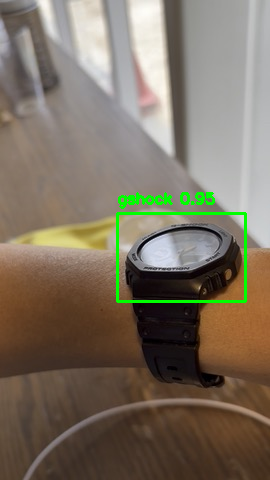

In [6]:
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO


model_path = '/content/runs/train/weights/best.pt'
image_path = '/content/test.jpg'

# 初始化 YOLO 模型
model = YOLO(model_path)  # 使用自訂模型

# 讀取影像
image = cv2.imread(image_path)

# 執行物件偵測
results = model(image)[0]

# 繪製矩形框和物件名稱
for result in results.boxes:
    # 取得邊界框座標
    x1, y1, x2, y2 = map(int, result.xyxy[0])
    # 取得物件名稱
    label = result.cls[0]
    confidence = result.conf[0]
    name = f"{model.names[int(label)]} {confidence:.2f}"

    # 繪製矩形框
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # 在矩形框上顯示物件名稱
    cv2.putText(image, name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 顯示結果影像
cv2_imshow(image)

